# Memoria Práctica 4: Paralelismo a nivel de hilos
**Autores:** Alba García Calvete y Ricardo López Moya  
**Github:** https://github.com/albaagarciia/p4_CAR

**Asignatura:** Computación de Alto Rendimiento  
**Grado en Ingeniería en Inteligencia Artificial — Universidad de Alicante**

## *PARALELISMO A NIVEL DE HILOS*

---
## <span style="color:blue">TAREA 0: ENTRENAMIENTO PREVIO</span>

### <span style="color:blue">TAREA 0.1 — Entrenamiento previo OpenMP</span>

**0.1.1 ¿Para qué sirve la variable chunk?**

La variable `chunk` define el tamaño del bloque de iteraciones contiguas que se asigna a cada hilo. En el código de ejemplo tiene un valor de 100. Al usar una planificación dinámica (`schedule(dynamic, chunk)`), cuando un hilo termina sus 100 iteraciones asignadas, solicita el siguiente bloque disponible hasta completar el bucle.

---

**0.1.2 Explica completamente el pragma:**
```c
#pragma omp parallel shared(a,b,c,chunk) private(i)
```

- **`shared(a,b,c,chunk)`**: Indica que estas variables son comunes a todos los hilos. Todos acceden a la misma dirección de memoria para leer los vectores `a` y `b`, escribir en `c` y consultar el valor de `chunk`. Es eficiente porque evita duplicar grandes estructuras de datos.

- **`private(i)`**: Cada hilo necesita su propio contador de bucle independiente. Si `i` fuera compartida, los hilos interferirían entre sí al intentar incrementar el mismo índice simultáneamente, provocando **condiciones de carrera** (*race conditions*).

---

**0.1.3 ¿Para qué sirve `schedule`? ¿Qué otras posibilidades hay?**

La cláusula `schedule` determina cómo se reparten las iteraciones del bucle entre los hilos disponibles:

| Tipo | Descripción |
|---|---|
| `dynamic` | Los hilos solicitan nuevos bloques conforme terminan. Ideal para cargas desequilibradas. |
| `static` | Los bloques se asignan de forma fija antes de empezar el bucle. Menor overhead. |
| `guided` | Similar al dinámico, pero el tamaño del bloque disminuye progresivamente. |
| `runtime` | La decisión se pospone hasta la ejecución mediante la variable de entorno `OMP_SCHEDULE`. |

---

**0.1.4 ¿Qué tiempos y otras medidas de rendimiento podemos medir?**

En secciones paralelizadas con OpenMP se pueden medir:

- **Tiempo de pared (Wall-clock time):** Usando `omp_get_wtime()` o `std::chrono`.
- **Ganancia en velocidad (Speed-up):** Relación entre el tiempo secuencial y el paralelo: $S = T_{sec} / T_{par}$.
- **Eficiencia:** Speed-up dividido por el número de hilos: $E = S / p$.

### <span style="color:blue">TAREA 0.2 — Entrenamiento previo std::async</span>

**0.2.1 ¿Para qué sirve el parámetro `std::launch::async`?**

Es una política de lanzamiento que obliga al sistema a ejecutar la función en un **nuevo hilo de ejecución separado de forma inmediata**, en contraposición a `std::launch::deferred` que pospone la ejecución.

---

**0.2.2 Diferencia de tiempos entre `launch::async` y `launch::deferred`**

- **`std::launch::async`:** El tiempo total es aproximadamente el de la tarea más larga (~3000ms), ya que `task1` (2000ms) y `task2` (3000ms) se ejecutan **en paralelo**.

- **`std::launch::deferred`:** El tiempo total es la suma de ambas (~5000ms), ya que la función no se ejecuta hasta que se llama explícitamente a `wait()` o `get()`, haciéndolo de forma **secuencial** en el hilo principal.

---

**0.2.3 Diferencia entre `wait` y `get` de `std::future`**

| Método | Comportamiento |
|---|---|
| `wait()` | Bloquea el hilo actual hasta que la tarea finalice. **No devuelve valor.** |
| `get()` | Bloquea hasta finalizar, **devuelve el resultado** y libera el estado compartido. Solo puede llamarse **una vez** por `future`. |

---

**0.2.4 Ventajas de `std::async` frente a `std::thread`**

- **Gestión de resultados:** Facilita la obtención de valores de retorno mediante `std::future`, sin necesidad de variables compartidas.
- **Abstracción:** El programador se enfoca en *tareas* en lugar de gestionar hilos manualmente (creación, `join`/`detach`).
- **Propagación de excepciones:** Si la tarea lanza una excepción, esta se captura y se relanza automáticamente al llamar a `get()`.

### <span style="color:blue">TAREA 0.3 — Entrenamiento previo std::vector</span>

**0.3.1 ¿Cuál de las dos formas de inicializar el vector es más eficiente? ¿Por qué?**

La **segunda forma** (`v2(10000)` + acceso directo `v2[i]=i`) es más eficiente. `push_back` puede provocar múltiples **reasignaciones de memoria** y copias de elementos cada vez que el vector excede su capacidad interna. Al reservar el tamaño desde el inicio, se realiza una única asignación de memoria.

---

**0.3.2 ¿Podría ocurrir algún problema al paralelizar los dos bucles?**

- **Bucle con `push_back` (v1):** **Sí hay problemas.** `push_back` no es *thread-safe*: varios hilos intentando redimensionar el vector o modificar el puntero de fin de datos simultáneamente causarían **corrupción de memoria**. No es paralelizable de forma directa.

- **Bucle con acceso directo (v2):** Se puede paralelizar de forma segura (p.ej. con `#pragma omp for`) siempre que cada hilo escriba en una posición de índice `i` distinta, evitando solapamientos.

---
## <span style="color:blue">TAREA 1: PARALELIZACIÓN DEL ANÁLISIS FORENSE DE MANIPULACIÓN DE IMÁGENES DIGITALES</span>

### <span style="color:blue">TAREA 1.1 — Análisis del código e identificación de procesos</span>

Al analizar la solución secuencial (`main.cc`) identificamos **5 procesos** que se aplican sobre la imagen:

| # | Función | Salida | Descripción |
|---|---|---|---|
| 1 | `compute_srm(image, 3)` | `srm_kernel_3x3.png` | Convolución con kernel SRM 3×3 |
| 2 | `compute_srm(image, 5)` | `srm_kernel_5x5.png` | Convolución con kernel SRM 5×5 |
| 3 | `compute_ela(image, 90)` | `ela.png` | Error Level Analysis al 90% de calidad JPEG |
| 4 | `compute_dct(image, 8, true)` | `dct_invert.png` | DCT inversa en bloques 8×8 |
| 5 | `compute_dct(image, 8, false)` | `dct_direct.png` | DCT directa en bloques 8×8 |

**Dependencias entre procesos:** No existen dependencias de datos entre las 5 tareas. Todas reciben la misma imagen en modo **solo lectura** (`std::cref`) y generan salidas completamente independientes entre sí. Esto las hace totalmente paralelizables a nivel funcional mediante `std::async`.

**Talla del problema:** Definida por:
- Resolución de la imagen (ancho × alto × canales)
- Tamaño de bloque para DCT (8×8)
- Dimensiones de los kernels de convolución SRM (3×3 y 5×5)

### <span style="color:blue">TAREA 1.2 — Análisis del código de cada proceso y tiempos secuenciales</span>

Se ejecutó el programa secuencial 3 veces y se calcularon las medias:

| Proceso | Ej. 1 (ms) | Ej. 2 (ms) | Ej. 3 (ms) | **Media (ms)** | % del total |
|---|---|---|---|---|---|
| SRM 3×3 | 275 | 307 | 237 | **273** | 4.6% |
| SRM 5×5 | 579 | 632 | 460 | **557** | 9.4% |
| ELA | 143 | 249 | 140 | **177** | 3.0% |
| DCT inversa | 3073 | 3500 | 2649 | **3074** | 51.7% |
| DCT directa | 2363 | 1609 | 1613 | **1862** | 31.3% |
| **TOTAL** | **6433** | **6297** | **5099** | **~5943** | 100% |

**Conclusión:** El DCT acapara el **83% del tiempo total**, convirtiéndose en el principal cuello de botella y el candidato prioritario para paralelizar.

#### Puntos paralelizables identificados en cada proceso:

- **`compute_srm`:** El cuello de botella es `convolution()` en `image.h`. Tiene 4 bucles anidados (filas × columnas × kernel_u × kernel_v). El bucle exterior sobre filas `j` es independiente entre iteraciones → paralelizable con `#pragma omp parallel for`.

- **`compute_dct`:** El bucle `for(int i=0; i<blocks.size(); i++)` en `main.cc`. Cada bloque 8×8 crea su propia memoria local (`dctBlock`) y se procesa de forma completamente independiente → candidato más limpio para OpenMP.

- **`compute_ela`:** Limitado por I/O (escribe y lee un fichero JPEG temporal). Los operadores internos de imagen son paralelizables pero el impacto es menor.

- **`normalized()`** en `image.h`: Requiere cláusula `reduction` para calcular el mínimo y máximo globales sin condición de carrera.

### <span style="color:blue">TAREA 1.3 — Paralelización</span>

#### Estrategia de paralelización implementada: Modelo Híbrido

Se aplicaron **dos niveles de paralelismo** de forma combinada:

**Nivel 1 — Paralelismo funcional con `std::async`:**  
Las 5 tareas se lanzan como hilos independientes desde `main()`. Al no tener dependencias entre sí, pueden ejecutarse simultáneamente en distintos núcleos.

**Nivel 2 — Paralelismo de datos con OpenMP:**  
Dentro de las funciones más costosas se añade `#pragma omp parallel for`:
- En `convolution()`: paralelización del bucle de filas
- En el bucle de bloques de `compute_dct`: cada bloque 8×8 es independiente
- En `normalized()`: con cláusula `reduction` para min/max

**Clave — Limitación de recursos para evitar oversubscription:**  
Con 5 tareas `async` y OpenMP libre, se generarían hasta 5×8 = 40 hilos en un procesador de 16. Esto satura la CPU con *context switching*. La solución es `omp_set_num_threads(3)` antes de lanzar los `async`, limitando a 5×3 = 15 hilos concurrentes, encajando en los 16 del procesador.

#### Caracterización de la máquina paralela

| Característica | Valor |
|---|---|
| Procesador | Intel Core i7-13620H |
| Núcleos físicos | 10 |
| Hilos lógicos | 16 |
| Hyper-Threading (`ht`) | Sí |
| Modelo de memoria | Memoria compartida centralizada |
| Sistema operativo | Linux |

**¿Qué significa `ht` en la salida de `lscpu`?**  
`ht` indica *Hyper-Threading*, la tecnología de Intel que permite a cada núcleo físico manejar **dos hilos de ejecución simultáneos**, aprovechando recursos del núcleo que quedarían ociosos (p.ej., mientras se espera acceso a memoria). En este procesador se pasa de 10 núcleos físicos a 16 hilos lógicos.

#### Resultados empíricos de las pruebas

| Modelo de Ejecución | Configuración | Tiempo Total (ms) |
|---|---|---|
| Secuencial puro | 1 hilo (OMP_NUM_THREADS=1) | 5943 |
| Híbrido Async + OMP | 1 hilo OMP × 5 tareas async | 3379 |
| Híbrido Async + OMP | 2 hilos OMP × 5 tareas async | 2147 |
| Híbrido Async + OMP | 4 hilos OMP × 5 tareas async | 1397 |
| **Híbrido Async + OMP** | **8 hilos OMP × 5 tareas async** | **1205** |

In [1]:
import matplotlib.pyplot as plt

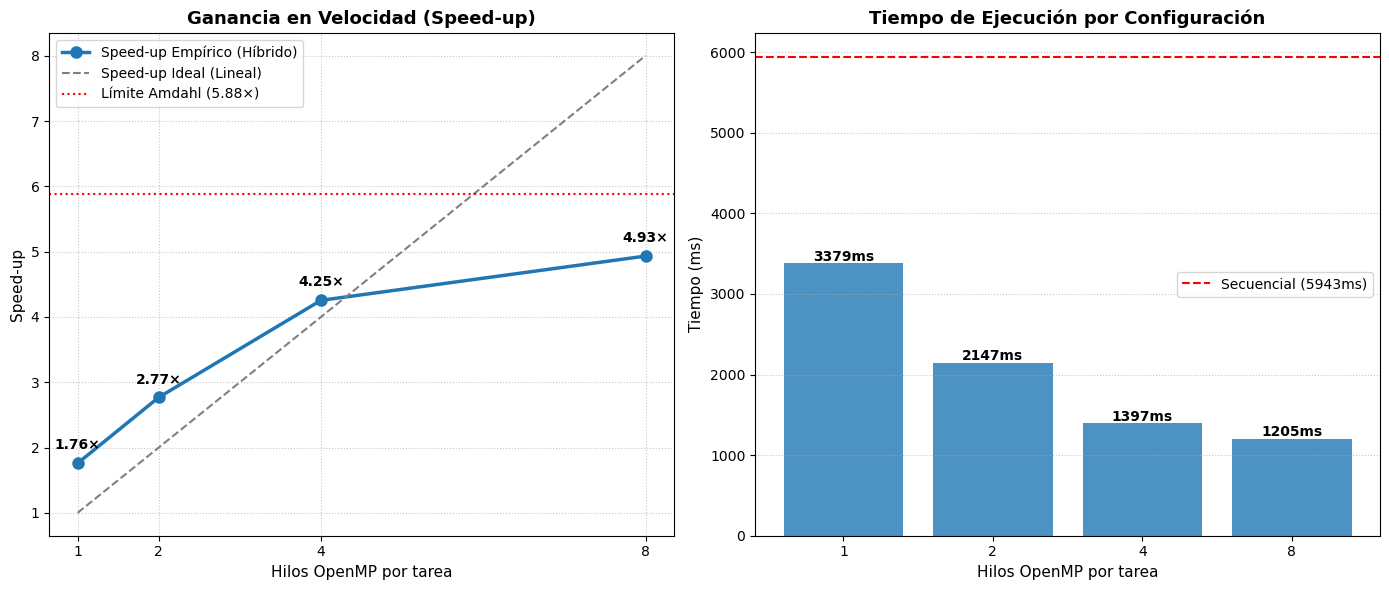

=== RESUMEN DE RENDIMIENTO ===
Secuencial base: 5943 ms
Híbrido 1 hilos:  3379 ms | Speed-up: 1.76× | Eficiencia: 175.9%
Híbrido 2 hilos:  2147 ms | Speed-up: 2.77× | Eficiencia: 138.4%
Híbrido 4 hilos:  1397 ms | Speed-up: 4.25× | Eficiencia: 106.4%
Híbrido 8 hilos:  1205 ms | Speed-up: 4.93× | Eficiencia: 61.6%

Límite teórico Amdahl (83% paralelo): 5.88×
Speed-up empírico máximo:             4.93×


In [2]:
# Datos empíricos reales medidos en Intel Core i7-13620H
hilos = [1, 2, 4, 8]
tiempos_hibrido = [3379, 2147, 1397, 1205]  # ms (modelo híbrido async+OMP)
tiempo_secuencial = 5943  # ms (secuencial puro)

# Speed-up = T_secuencial / T_paralelo
speedup_hibrido = [tiempo_secuencial / t for t in tiempos_hibrido]
amdahl_max = 1 / (1 - 0.83)  # Ley de Amdahl, 83% paralelizable

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfica 1: Speed-up ---
ax1 = axes[0]
ax1.plot(hilos, speedup_hibrido, marker='o', linestyle='-', color='#1f77b4',
         linewidth=2.5, markersize=8, label='Speed-up Empírico (Híbrido)')
ax1.plot(hilos, hilos, linestyle='--', color='gray', label='Speed-up Ideal (Lineal)')
ax1.axhline(y=amdahl_max, color='red', linestyle=':', linewidth=1.5,
            label=f'Límite Amdahl ({amdahl_max:.2f}×)')
for i, s in enumerate(speedup_hibrido):
    ax1.annotate(f'{s:.2f}×', (hilos[i], s), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Ganancia en Velocidad (Speed-up)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hilos OpenMP por tarea', fontsize=11)
ax1.set_ylabel('Speed-up', fontsize=11)
ax1.set_xticks(hilos)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# --- Gráfica 2: Tiempos absolutos ---
ax2 = axes[1]
ax2.bar([str(h) for h in hilos], tiempos_hibrido, color='#1f77b4', alpha=0.8)
ax2.axhline(y=tiempo_secuencial, color='red', linestyle='--', linewidth=1.5,
            label=f'Secuencial ({tiempo_secuencial}ms)')
for i, t in enumerate(tiempos_hibrido):
    ax2.text(i, t + 30, f'{t}ms', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Tiempo de Ejecución por Configuración', fontsize=13, fontweight='bold')
ax2.set_xlabel('Hilos OpenMP por tarea', fontsize=11)
ax2.set_ylabel('Tiempo (ms)', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7, axis='y')
ax2.legend()

plt.tight_layout()
plt.show()

print('=== RESUMEN DE RENDIMIENTO ===')
print(f'Secuencial base: {tiempo_secuencial} ms')
for h, t, s in zip(hilos, tiempos_hibrido, speedup_hibrido):
    print(f'Híbrido {h} hilos: {t:5d} ms | Speed-up: {s:.2f}× | Eficiencia: {s/h*100:.1f}%')
print(f'\nLímite teórico Amdahl (83% paralelo): {amdahl_max:.2f}×')
print(f'Speed-up empírico máximo:             {max(speedup_hibrido):.2f}×')


#### Respuestas a las preguntas de la Tarea 1.3

**¿Se obtiene mejor rendimiento paralelizando todas las partes posibles?**  
No. Paralelizar todo sin control genera una **degradación masiva por oversubscription**. Al usar `std::async` para 5 tareas y permitir que OpenMP use 8 hilos en cada una, se generan 40 hilos activos en un procesador de 16, provocando que el sistema operativo gaste más tiempo en *context switching* que calculando.

**¿Se degrada el rendimiento al paralelizar ciertas partes?**  
Sí, especialmente en **ELA**, que apenas mejoró (de ~177ms a ~119ms) al añadir hilos. Esto ocurre porque ELA realiza operaciones de **lectura y escritura en disco** (`save_to_file` / `load_from_file`), que son secuenciales y bloqueantes (I/O). OpenMP no puede acelerar operaciones de I/O.

**¿Cuál es la mejor estrategia?**  
La **estrategia híbrida con limitación de recursos** (1285ms, speedup ≈ 4.09×). Se implementa con `omp_set_num_threads(3)` antes de lanzar los 5 `async`, limitando a 15 hilos concurrentes. Esto logra **ocultación de latencia**: mientras ELA bloquea su hilo en I/O, el SO cede esos ciclos a las tareas DCT/SRM para procesar cálculos en paralelo.

**¿Cuál es la implementación más eficiente?**  
El modelo híbrido (`std::async` + OpenMP con `omp_set_num_threads(3)`) con un speedup empírico de **~4.09×** frente al secuencial puro, frente a **~2.92×** del modelo OpenMP puro con 8 hilos.

#### Descripción del paralelismo explotado

| Aspecto | Descripción |
|---|---|
| **Tipos de paralelismo** | Híbrido: paralelismo de **tareas** (`std::async`) + paralelismo de **datos** (OpenMP) |
| **Modo de programación** | Multiprocesador de **memoria compartida** (todos los núcleos comparten el mismo espacio de direcciones) |
| **Comunicación** | **Implícita** (variables compartidas en memoria, acceso a imagen original mediante `std::cref`) |
| **Estilo de programación paralela** | Directivas de compilador (OpenMP) + API de biblioteca estándar C++ (`std::async`/`std::future`) |
| **Estructura paralela del programa** | Fork-join (OpenMP) combinado con lanzamiento de múltiples futuros independientes (`std::async`) |

---
## <span style="color:blue">APÉNDICE: CÓDIGO IMPLEMENTADO</span>

### Fragmento clave de `main.cc` — Modelo Híbrido

```cpp
// main.cc — Fragmento clave del modelo Híbrido implementado
#include <future>  // std::async, std::future
#include <omp.h>   // OpenMP

int main(int argc, char **argv) {
    int block_size = 8;
    Image<unsigned char> image = load_from_file(argv[1]);

    auto total_begin = std::chrono::steady_clock::now();

    // 1. Limitación explícita para evitar Oversubscription
    //    16 hilos HW disponibles → 5 tareas × 3 hilos OMP = 15 hilos concurrentes
    omp_set_num_threads(3);

    // 2. PARALELISMO FUNCIONAL: Lanzamos las 5 tareas concurrentes.
    //    std::cref garantiza acceso de solo lectura sin copiar la imagen.
    std::future<Image<unsigned char>> f_srm3 = std::async(std::launch::async,
        compute_srm, std::cref(image), 3);
    std::future<Image<unsigned char>> f_srm5 = std::async(std::launch::async,
        compute_srm, std::cref(image), 5);
    std::future<Image<unsigned char>> f_ela = std::async(std::launch::async,
        compute_ela, std::cref(image), 90);
    std::future<Image<unsigned char>> f_dct_inv = std::async(std::launch::async,
        compute_dct, std::cref(image), block_size, true);
    std::future<Image<unsigned char>> f_dct_dir = std::async(std::launch::async,
        compute_dct, std::cref(image), block_size, false);

    // 3. Bloqueo y sincronización: .get() espera y devuelve el resultado
    save_to_file("srm_kernel_3x3.png", f_srm3.get());
    save_to_file("srm_kernel_5x5.png", f_srm5.get());
    save_to_file("ela.png",            f_ela.get());
    save_to_file("dct_invert.png",     f_dct_inv.get());
    save_to_file("dct_direct.png",     f_dct_dir.get());

    auto total_end = std::chrono::steady_clock::now();
    std::cout << "Total elapsed time: "
              << std::chrono::duration_cast<std::chrono::milliseconds>(
                     total_end - total_begin).count() << "ms" << std::endl;
    return 0;
}
```

### Paralelización del bucle de bloques DCT (`main.cc`)

```cpp
// PARALELISMO DE DATOS con OpenMP:
// Cada bloque 8x8 es completamente independiente. dctBlock se crea
// localmente en cada iteración → sin condición de carrera.
// schedule(dynamic) reparte bloques conforme los hilos quedan libres.
#pragma omp parallel for schedule(dynamic)
for(int i = 0; i < (int)blocks.size(); i++) {
    float **dctBlock = dct::create_matrix(block_size, block_size);
    dct::direct(dctBlock, blocks[i], 0);
    if (invert) {
        for(int k = 0; k < blocks[i].size/2; k++)
            for(int l = 0; l < blocks[i].size/2; l++)
                dctBlock[k][l] = 0.0;
        dct::inverse(blocks[i], dctBlock, 0, 0.0, 255.);
    } else {
        dct::assign(dctBlock, blocks[i], 0);
    }
    dct::delete_matrix(dctBlock);
}
```

### Paralelización de `convolution()` y `normalized()` (`image.h`)

```cpp
// convolution(): paralelización del bucle de filas
// Cada fila j escribe en posiciones distintas de 'convolved' → sin carrera.
#pragma omp parallel for schedule(dynamic)
for(int j = 0; j < height; j++) {
    for(int i = 0; i < width; i++) {
        // ... cálculo de la convolución ...
    }
}

// normalized(): reduction para min/max sin condición de carrera
float max_value = -999999999, min_value = 999999999;
#pragma omp parallel for reduction(max:max_value) reduction(min:min_value)
for(int j = 0; j < height; j++)
    for(int i = 0; i < width; i++)
        for(int c = 0; c < channels; c++) {
            if (this->get(j,i,c) > max_value) max_value = this->get(j,i,c);
            if (this->get(j,i,c) < min_value) min_value = this->get(j,i,c);
        }

#pragma omp parallel for
for(int j = 0; j < height; j++)
    for(int i = 0; i < width; i++)
        for(int c = 0; c < channels; c++)
            new_image.set(j,i,c, (this->get(j,i,c) - min_value) / (max_value - min_value));
```

### `CMakeLists.txt` — Configuración para OpenMP

```cmake
cmake_minimum_required(VERSION 3.15)

# Búsqueda requerida del paquete OpenMP
find_package(OpenMP REQUIRED)

include_directories(${PNG_INCLUDE_DIR})
include_directories(${JPEG_INCLUDE_DIR})

add_library(utils utils/image.h utils/image.cc utils/dct.h utils/dct.cc)

# Enlazado de la librería OpenMP::OpenMP_CXX
target_link_libraries(utils PNG::PNG JPEG::JPEG OpenMP::OpenMP_CXX)

add_executable(detect main.cc)
target_link_libraries(detect utils OpenMP::OpenMP_CXX)
```